In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("cleaned_data.csv")

In [9]:
df = df.iloc[:, 1:]

In [16]:
# df.replace({"category": {"misc": "Misc"}}, inplace=True)

In [18]:
df["category"].value_counts()
# misc -> Misc
# Fasteners -> Fasteners

category
Brackets & Mounts    45
Reinforcements       19
Fasteners            18
Body Panels          14
Misc                 10
brackets              4
General               4
Name: count, dtype: int64

In [21]:
df[df["category"].isin(["General", "Misc"])]

,part_id,part_description,supplier_name,plant_location,category,material_type,material_grade,unit_weight_kg,annual_volume,unit_price_local,currency,fiscal_year
21,PART-0022,Steering Column Bracket,Bharat Precision Stampings,Pune,Misc,Steel,DP780,1.390,60000,107.37,INR,FY26
23,PART-0005,Clip Retainer Plate,Kalyani Stamping Co,Sanand,Misc,Steel,dp780,0.362,150000,38.34,INR,FY26
26,PART-0066,Transmission Support Bracket,Anand Sheet Metal Ltd,Chennai,General,Steel,HSLA340,1.072,90000,70.98,INR,FY26
37,PART-0045,Engine Mount Bracket,Om Precision Tools,Chennai,Misc,Steel,dp780,1.730,24000,167.89,INR,FY26
46,PART-0064,Clip Retainer Plate,Om Precision Tools,Chakan,Misc,Steel,cr3,1.223,60000,94.32,INR,FY26
50,PART-0010,Chassis Mount Bracket,Om Precision Tools,Gurugram,Misc,Steel,DP780,1.704,5000,180.37,INR,FY26
55,PART-0023,Exhaust Hanger Bracket,Anand Sheet Metal Ltd,Pantnagar,Misc,Steel,HSLA 340,2.275,90000,207.39,INR,FY26
58,PART-0019,Bumper Reinforcement Beam,Vindhya Metal Works,Chakan,Misc,Steel,CR-3,1.592,60000,150.65,INR,FY26
62,PART-0073,Sill Reinforcement Plate,Shivam Forge Pvt Ltd,Sanand,General,Steel,dp780,0.604,24000,60.69,INR,FY26
65,PART-0100,Weld Nut Assembly,Shivam Forge Pvt Ltd,Chakan,Misc,Steel,if steel,1.072,48000,70.55,INR,FY26


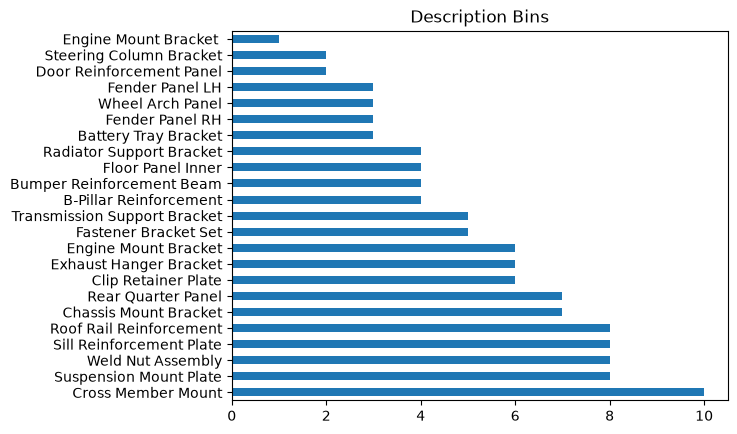

In [26]:
import matplotlib.pyplot as plt

df["part_description"].value_counts().plot(kind="barh")
plt.title("Description Bins")
plt.ylabel("")
plt.show()

In [29]:
BROAD_DESCRIPTION_BINS = [
    "Panel",
    "Bracket",
    "Plate",
    "Mount",
    "Beam",
    "Nut",
    "Rail",
    "Pillar",
]
# Broadly the descriptions can be binned into these labels (Infered from Nouns)

In [30]:
# Making Broad Bins

In [33]:
df["part_description"].unique().tolist()

['B-Pillar Reinforcement',
 'Suspension Mount Plate',
 'Clip Retainer Plate',
 'Bumper Reinforcement Beam',
 'Exhaust Hanger Bracket',
 'Weld Nut Assembly',
 'Engine Mount Bracket',
 'Cross Member Mount',
 'Chassis Mount Bracket',
 'Sill Reinforcement Plate',
 'Roof Rail Reinforcement',
 'Fastener Bracket Set',
 'Door Reinforcement Panel',
 'Steering Column Bracket',
 'Rear Quarter Panel',
 'Transmission Support Bracket',
 'Battery Tray Bracket',
 'Engine Mount Bracket ',
 'Floor Panel Inner',
 'Radiator Support Bracket',
 'Fender Panel RH',
 'Wheel Arch Panel',
 'Fender Panel LH']

## Regex Matching

In [34]:
import re

pattern = r"\b(" + "|".join(BROAD_DESCRIPTION_BINS) + r")\b"

df["description_bin"] = (
    df["part_description"]
    .str.extract(pattern, flags=re.IGNORECASE, expand=False)
    .str.title()
)

In [37]:
subset_df = df[["part_description", "category", "description_bin"]]

In [39]:
subset_df[subset_df["category"] == "Misc"]

,part_description,category,description_bin
21,Steering Column Bracket,Misc,Bracket
23,Clip Retainer Plate,Misc,Plate
37,Engine Mount Bracket,Misc,Mount
46,Clip Retainer Plate,Misc,Plate
50,Chassis Mount Bracket,Misc,Mount
55,Exhaust Hanger Bracket,Misc,Bracket
58,Bumper Reinforcement Beam,Misc,Beam
65,Weld Nut Assembly,Misc,Nut
79,Fender Panel LH,Misc,Panel
114,Roof Rail Reinforcement,Misc,Rail


## Misc can be reduced to description_bin categories for more descriptive analogy.

In [42]:
subset_df.groupby("category")["description_bin"].unique()

category
Body Panels                                                  [Panel]
Brackets & Mounts                       [Mount, Bracket, Panel, Nut]
Fasteners                               [Plate, Nut, Bracket, Panel]
General                                [Bracket, Plate, Rail, Panel]
Misc                 [Bracket, Plate, Mount, Beam, Nut, Panel, Rail]
Reinforcements                    [Pillar, Beam, Plate, Panel, Rail]
brackets                                              [Mount, Plate]
Name: description_bin, dtype: object

In [43]:
# Why Panel is distributed across multiple categories ?

In [54]:
panel_df = (
    df[
        [
            "part_description",
            "supplier_name",
            "plant_location",
            "material_type",
            "description_bin",
            "category",
        ]
    ]
    .set_index("description_bin")
    .loc["Panel"]
)

In [55]:
panel_df

,part_description,supplier_name,plant_location,material_type,category
description_bin,,,,,
Panel,Door Reinforcement Panel,Om Precision Tools,Pune,Steel,Reinforcements
Panel,Rear Quarter Panel,Anand Sheet Metal Ltd,Sanand,Steel,Body Panels
Panel,Door Reinforcement Panel,Kalyani Stamping Co,Chakan,Steel,Brackets & Mounts
Panel,Floor Panel Inner,Suresh Auto Components,Pune,Steel,Body Panels
Panel,Rear Quarter Panel,Om Precision Tools,Chakan,Steel,Body Panels
Panel,Rear Quarter Panel,Om Precision Tools,Gurugram,Steel,Body Panels
Panel,Fender Panel RH,Kalyani Stamping Co,Sanand,Steel,Body Panels
Panel,Floor Panel Inner,Suresh Auto Components,Pune,Steel,Body Panels
Panel,Wheel Arch Panel,Ganga Auto Forgings,Pune,Steel,Brackets & Mounts


## Panel Bins are wrongly distributed, eg. Om precision Tools
- Wheel Arch Panel  -> Body Panels
- Fender Panel RH -> Fasteners
- Rear Quarter Panel -> Body Panels

### Every Panel belongs to steel category but categorised wrongly, both Fender Panel RH(Right Hand) and Rear Quarter Panel are same things. Should be categorised into Panel

## Bracket POV

In [65]:
df.groupby(["supplier_name", "category"])["description_bin"].unique()

supplier_name                 category         
Anand Sheet Metal Ltd         Body Panels                                     [Panel]
                              Brackets & Mounts                      [Bracket, Mount]
                              Fasteners                                [Nut, Bracket]
                              General                                       [Bracket]
                              Misc                                          [Bracket]
                              Reinforcements              [Plate, Rail, Pillar, Beam]
Bharat Precision Stampings    Brackets & Mounts                      [Mount, Bracket]
                              Fasteners                                [Nut, Bracket]
                              Misc                                          [Bracket]
                              Reinforcements                      [Beam, Plate, Rail]
Ganga Auto Forgings           Body Panels                                     [Panel]
      

In [73]:
SUBSET_COLS = [
    "part_description",
    "category",
    "supplier_name",
    "material_type",
    "description_bin",
]

In [75]:
brckt_df = df.set_index("description_bin").loc["Bracket"].reset_index()[SUBSET_COLS]

- If descrption is Fastener Bracket Set and Category is Fastener, Treating as Right as they are a specilaised kit used in manufacturing and should'nt be catgorised as just brackets.

In [83]:
brckt_df = brckt_df[
    ~(
        (brckt_df["part_description"] == "Fastener Bracket Set")
        & (brckt_df["category"] == "Fasteners")
    )
]

In [90]:
brckt_df
# Reduce to Brackets and Mounts

,part_description,category,supplier_name,material_type,description_bin
0,Exhaust Hanger Bracket,Brackets & Mounts,Suresh Auto Components,Steel,Bracket
2,Steering Column Bracket,Misc,Bharat Precision Stampings,Steel,Bracket
3,Exhaust Hanger Bracket,Brackets & Mounts,Anand Sheet Metal Ltd,Steel,Bracket
4,Transmission Support Bracket,General,Anand Sheet Metal Ltd,Steel,Bracket
5,Battery Tray Bracket,Brackets & Mounts,Om Precision Tools,Steel,Bracket
6,Transmission Support Bracket,Brackets & Mounts,Shivam Forge Pvt Ltd,Steel,Bracket
8,Radiator Support Bracket,Fasteners,Bharat Precision Stampings,Steel,Bracket
10,Transmission Support Bracket,Brackets & Mounts,Shivam Forge Pvt Ltd,Steel,Bracket
11,Radiator Support Bracket,Brackets & Mounts,Vindhya Metal Works,Steel,Bracket
12,Exhaust Hanger Bracket,Misc,Anand Sheet Metal Ltd,Steel,Bracket


In [ ]:
brckt_df = brckt_df[
    ~(
        (brckt_df["part_description"] == "Fastener Bracket Set")
        & (brckt_df["category"] == "Fasteners")
    )
]


In [ ]:
# brckt_df["category"] = "Brackets & Mounts"

In [115]:
df.loc[
    (df["description_bin"] == "Bracket")
    & ~(
        (df["category"] == "Fasteners")
        & (df["part_description"] == "Fastener Bracket Set")
    ),
    "category",
] = "Brackets & Mounts"

In [123]:
df.loc[(df["description_bin"] == "Panel"), "category"] = "Body Panels"

In [134]:
df.loc[(df["part_id"] == "PART-0091"), "category"] = "Brackets & Mounts"

In [138]:
df[df["category"].isna()]

,part_id,part_description,supplier_name,plant_location,category,material_type,material_grade,unit_weight_kg,annual_volume,unit_price_local,currency,fiscal_year,description_bin
15,PART-0103,Roof Rail Reinforcement,Shivam Forge Pvt Ltd,Chakan,NaN,Steel,hsla340,2.9,150000,220.04,INR,FY26,Rail


In [143]:
df.loc[(df["part_id"] == "PART-0103"), "category"] = "Rail"

In [146]:
df.isna().sum()
# Imputation Complete

part_id             0
part_description    0
supplier_name       0
plant_location      0
category            0
material_type       0
material_grade      0
unit_weight_kg      0
annual_volume       0
unit_price_local    0
currency            0
fiscal_year         0
description_bin     0
dtype: int64

In [149]:
df.to_csv("cleaned_data_v2.csv", index=False)

In [151]:
df["category"].value_counts()

category
Brackets & Mounts    48
Body Panels          22
Reinforcements       18
Fasteners            15
Misc                  7
brackets              4
General               2
Rail                  1
Name: count, dtype: int64

In [157]:
df.loc[(df["part_description"] == "Roof Rail Reinforcement"), "category"] = "Rail"

In [159]:
df["category"].value_counts()

category
Brackets & Mounts    48
Body Panels          22
Fasteners            15
Reinforcements       13
Rail                  8
Misc                  6
brackets              4
General               1
Name: count, dtype: int64

In [165]:
df.loc[(df["category"] == "Misc")]

,part_id,part_description,supplier_name,plant_location,category,material_type,material_grade,unit_weight_kg,annual_volume,unit_price_local,currency,fiscal_year,description_bin
23,PART-0005,Clip Retainer Plate,Kalyani Stamping Co,Sanand,Misc,Steel,dp780,0.362,150000,38.34,INR,FY26,Plate
37,PART-0045,Engine Mount Bracket,Om Precision Tools,Chennai,Misc,Steel,dp780,1.730,24000,167.89,INR,FY26,Mount
46,PART-0064,Clip Retainer Plate,Om Precision Tools,Chakan,Misc,Steel,cr3,1.223,60000,94.32,INR,FY26,Plate
50,PART-0010,Chassis Mount Bracket,Om Precision Tools,Gurugram,Misc,Steel,DP780,1.704,5000,180.37,INR,FY26,Mount
58,PART-0019,Bumper Reinforcement Beam,Vindhya Metal Works,Chakan,Misc,Steel,CR-3,1.592,60000,150.65,INR,FY26,Beam
65,PART-0100,Weld Nut Assembly,Shivam Forge Pvt Ltd,Chakan,Misc,Steel,if steel,1.072,48000,70.55,INR,FY26,Nut


In [167]:
mask = df["category"].eq("Misc")
df.loc[mask, "category"] = df.loc[mask, "description_bin"]

In [178]:
df.loc[
    (df["category"] == "brackets") & (df["description_bin"] == "Mount"), "category"
] = "Brackets & Mounts"

In [180]:
df.to_csv("cleaned_data_v3.csv", index=False)

In [183]:
df.head().to_csv("sampel_data.csv", index=False)